# Lab 2:   ATLAS Data Analysis



Reminder:  **Lab 2** needs to be submitted in the `Lab2` folder of your personal `PHYS265-spring26` github repo, with the two `lab2.ipynb` and `lab2.html` files.

Lab days: April 6 and 8, during normal class hours.  Report is due on Sunday April 12, at 11.59pm on github, not ELMS.

Avoiding confusion, enter your name here:    Sam Harrison


## Introduction
------

Imagine you are a physicist working on the ATLAS (**A** **T**oroidal **L**hc **A**pparatu**S**) experiment at CERN in Geneva. At ATLAS, high energy protons are smashed together, and the byproducts are studied. One of the most important measurements to be made is the mass of the $Z^0$ boson.

After you have done your investigations — which you are guided through below — you will
prepare a short report on your findings for grad students in your research group in the form of this notebook. 

A table of relevant physical constants, from the 2024 edition of the Particle Data Group, is
below. Good luck!



| Quantity | Value |
|----------|-------|
|    Mass of Z Boson ($m_{Z^0}$) | $91.1880 \pm 0.0020$ GeV/$c^2$ |
|    Mass of W Boson ($m_W$) | $80.3692 \pm 0.0133$ GeV/$c^2$ |
|    Mass of Higgs Boson ($m_H$)   | $125.20 \pm 0.11$ GeV/$c^2$ |
|    Mass of Electron ($m_e$)   | $0.51099895000 \pm 0.00000000015$ MeV/$c^2$ |
|    Mass of Muon ($m_\mu$)   | $105.6583755 \pm 0.0000023$ MeV/$c^2$ |
|    Mass of Tau ($m_\tau$)   | $1776.93 \pm 0.09$ MeV/$c^2$ |


At the Large Hadron Collider, at CERN, in Geneva, Switzerland, particle physicists collide beams of protons.
This process breaks the protons open, and more fundamental particles are formed, interact, and decay.
One of the most interesting fundamental particles to come out of proton-proton ($pp$) interactions is the $Z^0$-boson, which is the neutral carrier of the *weak* force, and is therefore responsible, along with the $W^{\pm}$-boson, for facilitating many nuclear interactions in the Universe. The photon, which you are more familiar with, is the carrier of the *electromagnetic force*.

The $Z^0$ is unstable and decays. About 10\% of the time, it decays into a pair of charged leptons. 
This can be an electron ($e$) and and anti-electron (or positron, $e^+$).
It can also be a muon/anti-muon pair, or a tau/anti-tau pair.
Because it can do any of these, we substitute the generic letter $\ell$ for lepton, 
and this interaction is known as $Z^0 \rightarrow \ell \bar{\ell}$, 
where the ``bar" over the $\ell$ indicates an anti-particle.
Because charge cannot be created or destroyed, they must have opposite 
(or no\footnote{It is also possible for the $Z^0$ to decay into two photons, or $Z^0 \rightarrow \gamma \gamma$}) 
charge. And, because matter and energy cannot be created or destroyed, 
if $Z^0$ particles are decaying to produce the leptons, 
then the total energy stored in the two leptons must sum to (at least) the mass of the $Z^0$.
This means that if we can measure the energy of all double-lepton events in the detector, 
we should see an *excess* or a *peak* at the mass of the $Z_0$.





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.stats as st

m_Z0 = 91.1880 
m_Z0_err = 0.0020

m_W = 80.3692      
m_W_err = 0.0133

m_H = 125.20
m_H_err = 0.11

m_e = 0.00051099895000
m_e_err = 0.0000000015

m_mu = 0.1056583755
m_mu_err = 0.0000023

m_tau = 1.77693   
m_tau_err = 0.09

### Part 1: Invariant Mass Distribution
------

In the ATLAS detector (which is one of four main experiments at the LHC), 
it is reasonably straightforward to measure four properties of particles 
that come out of the proton-proton interactions. The first is the total energy $E$. 
The second is the transverse-momentum $p_T$, which describes the momentum 
the particle has in the transverse direction. The third is the pseudorapidity $\eta$, 
which describes the angle the particle makes with respect to the beamline. 
If the particle continues straight along the beamline, then $\eta \rightarrow \infty$, 
while if the particle is deflected out at $90^o$, it has $\eta =0$. 
The fourth is the azimuthal angle $\phi$ about the beam. 
That is, if you are staring down the barrel of the collider, a particle with $\eta, \phi = 0, 0$ 
emerges from the interaction point flying directly to the right. 
Where a particle with $\eta, \phi = 0, \pi/2$ emerges from the top flying straight up.

Together, these values fully define the *four momentum* of the particle: 
$p = (E, p_x, p_y, p_z)$ through the following mathematical relationships, 
where $c$ (the speed of light) is treated in a strange fashion and set equal to 1 
(which you will learn more about when you take a course that covers relativity and discuss "natural units"):

$$
p_x = p_T \cos(\phi), \,\,\,\,\, p_y = p_T \sin(\phi), \,\,\,\, p_z = p_T \sinh(\eta)    \tag{1}
$$


The difference between the three-momentum and the energy is the particle's invariant mass:

$$
M = \sqrt{E^2 - (p_x^2 + p_y^2 + p_z^2)}     \tag{2}
$$

If you have *two* particles, and you would like to know the total momentum of the system, 
you have to sum the four momenta: $p_{tot} = p_1 + p_2$.

In the file `atlas_z_to_ll.csv`, you will find five-thousand real ATLAS data events.
These have been pre-selected from the 
[2020 ATLAS open dataset](https://atlas.cern/Resources/Opendata)
so that the ``final states" only contain the two leptons we are interested in.
The first two columns are the $p_T$ (in GeV) for the two leptons; 
the next two columns are the $\eta$, the next two are $\phi$ (radians), 
and the last two are the energy $E$ (in GeV) 
**Note**: One nifty utility of natural units is that momentum and energy have the same units, which makes doing math with them much easier.


1. Load the data into python.
2. For each lepton pair, using the formulas in eq. (1) and eq. (2), calculate the mass of a hypothetical particle which decayed to produce that pair.
   * Hint: first, calculate the vector components, then calculate the summed four-momenta, then calculate the mass.
4. Make a histogram, with error bars, of your calculated invariant mass. You should approximate this as a Poisson counting experiment, so that the error on the number of events in the bin is equal to the square-root of the number of events in the bin. That is: $\sigma = \sqrt{N}$. Label the axes nicely, with units, etc. To make uniform grading possible, please do the histogram from 80 to 100 GeV with 41 bins. That is: `bins = np.linspace(80,100,41)`.


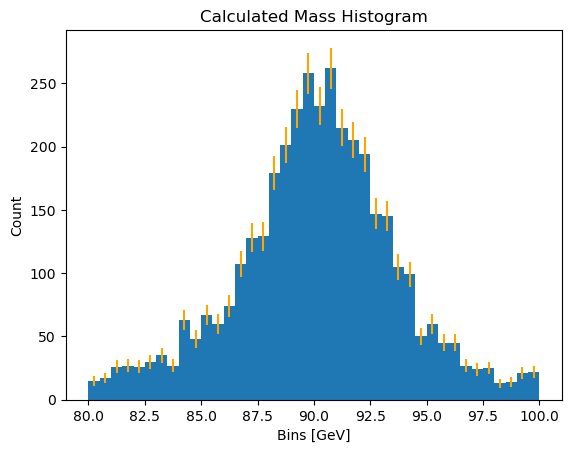

In [2]:
atlasdf = pd.read_csv('atlas_z_to_ll.csv')
pt1 = np.array(atlasdf['pt1'])
pt2 = np.array(atlasdf['pt2'])
eta1 = np.array(atlasdf['eta1'])
eta2 = np.array(atlasdf['eta2'])
phi1 = np.array(atlasdf['phi1'])
phi2 = np.array(atlasdf['phi2'])
E1 = np.array(atlasdf['E1'])
E2 = np.array(atlasdf['E2'])

px1 = pt1 * np.cos(phi1)
py1 = pt1 * np.sin(phi1)
pz1 = pt1 * np.sinh(eta1)
px2 = pt2 * np.cos(phi2)
py2 = pt2 * np.sin(phi2)
pz2 = pt2 * np.sinh(eta2)

og_px = px1 + px2
og_py = py1 + py2
og_pz = pz1 + pz2
og_E = E1 + E2

fig, ax = plt.subplots()
ogM = np.sqrt(og_E*og_E - (og_px*og_px + og_py*og_py + og_pz*og_pz))
bins0 = np.linspace(80,100,41)
counts, bin_edges, patches = ax.hist(ogM, bins=bins0)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 
errors = np.sqrt(counts)
ax.errorbar(x=bin_centers, y=counts, yerr=errors, fmt='None', color='orange')
ax.set_xlabel("Bins [GeV]")
ax.set_ylabel("Count")
ax.set_title("Calculated Mass Histogram")
plt.show()

### Part 2: Breit-Wigner Fit
------

You can show, using scattering theory, that the distribution of decays $\mathcal{D}$ at a reconstructed mass $m$ follows what is known as a Breit-Wigner (to a mathematician, Cauchy-Lorentz) peak. The distribution depends on true rest-mass of the $Z^0$, $m_0$, and on a "width" parameter $\Gamma$:

$$
\mathcal{D}(m; m_0, \Gamma) = \frac{1}{\pi} \frac{\Gamma/2}{(m-m_0)^2 + (\Gamma/2)^2}    \tag{3}
$$

In nature, the true width parameter $\Gamma_0$, is related to the lifetime of the particle by the Heisenberg uncertainty principle.
In a real detector, we can only measure the width subject to experimental uncertainties, and $\Gamma_{exp} > \Gamma_0$.


1. Code up a function that returns the decay distribution as a function of $m$, $m_0$, and $\Gamma$.
2.  Fit your mass-distribution with the Breit-Wigner function. Fix the overall normalization to half the number of data points in the set. That is, you should fit $\frac{5000}{2} \times \mathcal{D}$. To make
 uniform grading possible, please do the fitting where the bin centers are $>87$ to $<93$ GeV *only*. But keep the same 41 bins from 80 to 100. If you were to make a numpy mask, it would be: `mask = (bin_centers > 87) & (bin_centers < 93)`.
3. In a second, new plot, plot the data (with error bars), and overlay your fit. Label the axes well, add a nice legend, etc. In a sub-panel, plot the residuals between the data and the fit, and draw a hori
zontal line at zero to indicate perfect agreement (like we did in Lecture 13). Draw two vertical dotted lines to denote the fitting range.
4. Calculate the chi-square, reduced-chi-square, and p-value of your fit *in the fitting range*. 
5. Using the covariance matrix, calculate the best fit mass $m_0$, and its uncertainty. 
6. Annotate your plot with your best fit for the mass, its uncertainty, the chi-square/NDOF, and the p-value. Use only one decimal place for all numbers. 
7. Label this plot clearly as **Figure 1**.




Chi2 for the Fit: 9.420909088746525
Reduced Chi2 for the Fit: 0.9420909088746525
p-value: 0.49267698797137116
m0 Fit: 90.31958057449597 with error 0.09486895019013172


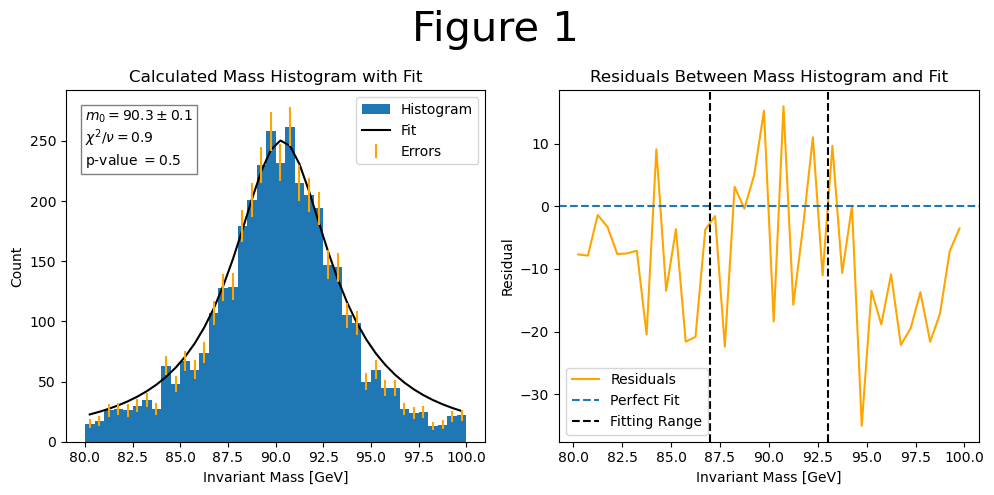

In [3]:
def D(m, m0, Gamma):
    return (1/np.pi) * (Gamma/2) / ( (m - m0)**2 + (Gamma/2)**2 )
    
def Dfit(m, m0, Gamma):
    return 2500 * D(m,m0,Gamma)
mask = (bin_centers > 87) & (bin_centers < 93)
fit, cov = curve_fit(Dfit, xdata=bin_centers[mask], ydata=counts[mask])

fig2, (ax2, ax3) = plt.subplots(1,2, figsize=(10,5))
counts, bin_edges, patches = ax2.hist(ogM, bins=bins0, label="Histogram")
ax2.plot(bin_centers, Dfit(bin_centers, fit[0], fit[1]), color='black', label="Fit")
ax2.errorbar(x=bin_centers, y=counts, yerr=errors, fmt='None', color='orange', label="Errors")
ax2.set_xlabel("Invariant Mass [GeV]")
ax2.set_ylabel("Count")
ax2.set_title("Calculated Mass Histogram with Fit")
ax2.legend()

residuals = counts - Dfit(bin_centers, fit[0], fit[1])
ax3.plot(bin_centers, residuals, color='orange', label="Residuals")
ax3.set_title("Residuals Between Mass Histogram and Fit")
ax3.set_xlabel("Invariant Mass [GeV]")
ax3.set_ylabel("Residual")
ax3.axhline(y=0, linestyle='--', label="Perfect Fit")
ax3.axvline(x=87, color='black', linestyle='--', label="Fitting Range")
ax3.axvline(x=93, color='black', linestyle='--') 
ax3.legend()
fig2.suptitle("Figure 1", fontsize=30)
fig2.tight_layout()



expected_counts = Dfit(bin_centers, fit[0], fit[1])[mask]
chi2 = np.sum(residuals[mask]*residuals[mask] / expected_counts) # using counts as sigma^2 since from before sigma = sqrt(counts)
print(f"Chi2 for the Fit: {chi2}")
red_chi2 = chi2 / (len(counts[mask]) - 2)    # since we have 2 fitting parameters
print(f"Reduced Chi2 for the Fit: {red_chi2}")
p_value = st.chi2.sf(chi2, len(counts[mask]) - 2)
print(f"p-value: {p_value}")

m0_error, Gamma_error = np.sqrt(np.diag(cov))
print(f"m0 Fit: {fit[0]} with error {m0_error}")
ax2.text(x=80, y=230, s=rf"$m_0 = {fit[0]:.1f} \pm {m0_error:.1f}$" "\n" rf"$\chi^2 / \nu = {red_chi2:.1f}$" "\n" rf"p-value $= {p_value:.1f}$", bbox=dict(boxstyle="square, pad=0.3", facecolor='None', alpha=0.5))
plt.show()

## Part 3: 2D Parameter Scan
----

As emphasized in class, this is a 2D fit, and you cannot determine $Z^0$ and $\Gamma_{exp}$ independently. In this part, you visualize the joint probability space.


1. Perform a 2D chi-square scan of the mass-width parameter space. To make grading easier, please scan in  mass from 89 to 91 GeV, and the width from 5 to 8, with 300 bins along each dimension. 
2. Make a filled contour plot of the $\Delta \chi^2 = \chi^2 - \chi^2_{min}$. Clip the $\Delta \chi^2$ at 35 units to make the plot easier to see. Add a colorbar. Make the plot look nice, with appropriate labels. Note that this is a $\Delta \chi^2$ map. This means the minimum value on the z-axis should be zero.
3. Draw the $1\sigma$ and $3\sigma$ confidence levels onto the plot using a solid and dashed line, respectively.  Use the matplotlib `clabel` capability to label the levels appropriately.
   * Hint 1: If you need a refresher on how to do this, please check [this matplotlib page](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_label_demo.html)
   * Hint 2: You can look up the $\Delta \chi^2$ corresponding to the $1\sigma$ and $3\sigma$ levels online, or they can be seen in Lecture **11**. Pay close attention to how many degrees of freedom you have.
5. Draw a dot/cross at the best fit location from Part 2.
6. Label this plot clearly as **Figure 2**.




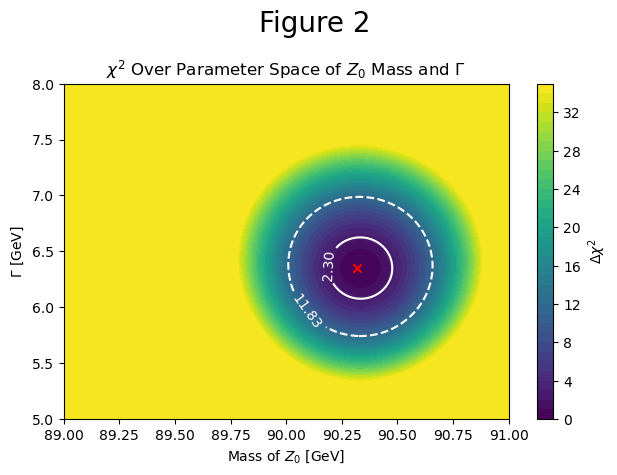

In [4]:
Z0 = np.linspace(89,91,300)
Gamma_exp = np.linspace(5,8,300)
m0_grid, Gamma_exp_grid = np.meshgrid(Z0, Gamma_exp)

counts_3d = counts[mask, None, None]
m = bin_centers[mask, None, None]

exp_scan = Dfit(m, m0_grid, Gamma_exp_grid)
residuals_scan = counts_3d - exp_scan
chi2_scan = np.sum((residuals_scan**2)/ exp_scan, axis=0)

chi2_min = np.min(chi2_scan)
delta_chi2 = chi2_scan - chi2_min

fig3, ax4 = plt.subplots()
fig3.suptitle("Figure 2", fontsize=20)
levels = np.linspace(0,35,36)
contour = ax4.contourf(m0_grid, Gamma_exp_grid, np.clip(delta_chi2, a_min=0, a_max=35), levels=levels, cmap='viridis');
fig3.colorbar(contour, label=r"$\Delta\chi^2$");
sigma_lines = ax4.contour(m0_grid, Gamma_exp_grid, delta_chi2, levels=[2.30, 11.83], colors='white', linestyles=['solid','dashed'])
ax4.clabel(levels=[2.30, 11.83], CS=sigma_lines);
ax4.scatter(x=fit[0], y=fit[1], marker='x', color='red');
ax4.set_xlabel(r"Mass of $Z_0$ [GeV]")
ax4.set_ylabel(r"$\Gamma$ [GeV]");
ax4.set_title(r"$\chi^2$ Over Parameter Space of $Z_0$ Mass and $\Gamma$");
fig3.tight_layout()
plt.show()

## Part 4: Discussion and Future Work
----

Add a brief comparison of your measured $Z^0$ relative to
the latest accepted values from the PDG. It should also include a summary of the approximations
you have made in doing your calculations, and future work necessary to make the calculations
more realistic. For example, your fit does not include any systematic uncertainties, or the energy
resolution of the ATLAS detector.


The latest accepted value from the PDG is $91.1880 \pm 0.0020$ GeV. Using our calculated error (since it dominates the error from the PDG error,) our calculated value is over $9\sigma$ from the measured value, which is a very poor agreement with an essentially negligible p-value.

We do not propagate any systematic uncertainties in our error, such as the energy or momentum scale being slightly mis-calibrated or the detector being slightly misaligned. Moreover, the approximation we made for the model (assuming that the distribution was a perfectly symmetrical Breit-Wigner model) may deviate from the likely skewed real distribution. This is, in our opinion, the most likely culprit behind the extremely low mass measurement. 

We also did not fit our normalization constant, and used Poisson errors even for bins with too low a count for that statistical theory to dominate random errors. Future work might drop these approximations, or work with a larger data set to avoid random skew or random deviation from Poisson errors. 